In [1]:
%pip install nltk pyspellchecker pandas matplotlib seaborn

   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/7.2 MB 2.2 MB/s eta 0:00:03
   ----- ---------------------------------- 1.0/7.2 MB 1.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/7.2 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 1.8/7.2 MB 1.8 MB/s eta 0:00:03
   ----------- ---------------------------- 2.1/7.2 MB 1.7 MB/s eta 0:00:03
   -------------- ------------------------- 2.6/7.2 MB 1.9 MB/s eta 0:00:03
   --------------- ------------------------ 2.9/7.2 MB 1.9 MB/s eta 0:00:03
   ------------------ --------------------- 3.4/7.2 MB 1.8 MB/s eta 0:00:03
   ----------------------- ---------------- 4.2/7.2 MB 2.0 MB/s eta 0:00:02
   --------------------------- ------------ 5.0/7.2 MB 2.1 MB/s eta 0:00:02
   ------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.probability import FreqDist

from collections import Counter, defaultdict
from spellchecker import SpellChecker

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

print("NLTK resources downloaded successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...


NLTK resources downloaded successfully!


[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sravy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
with open("corpus.txt", "r", encoding="utf-8") as file:
    text = file.read()

print("Corpus loaded successfully!")
print("Number of characters:", len(text))
print("\nFirst 500 characters:\n")
print(text[:500])

Corpus loaded successfully!
Number of characters: 163950

First 500 characters:

The Project Gutenberg eBook of Alice's Adventures in Wonderland
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online
at www.gutenberg.org. If you are not located in the United States,
you will have to check the laws of the country where you are located
before using 


In [5]:
tokens = word_tokenize(text.lower())

stop_words = set(stopwords.words("english"))

clean_tokens = [
    word for word in tokens
    if word.isalpha() and word not in stop_words
]

print("Original tokens:", len(tokens))
print("Clean tokens:", len(clean_tokens))
print("\nSample tokens:")
print(clean_tokens[:30])

Original tokens: 38043
Clean tokens: 13252

Sample tokens:
['project', 'gutenberg', 'ebook', 'alice', 'adventures', 'wonderland', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'parts', 'world', 'cost', 'almost', 'restrictions', 'whatsoever', 'may', 'copy', 'give', 'away', 'terms', 'project', 'gutenberg', 'license', 'included', 'ebook', 'online', 'located']


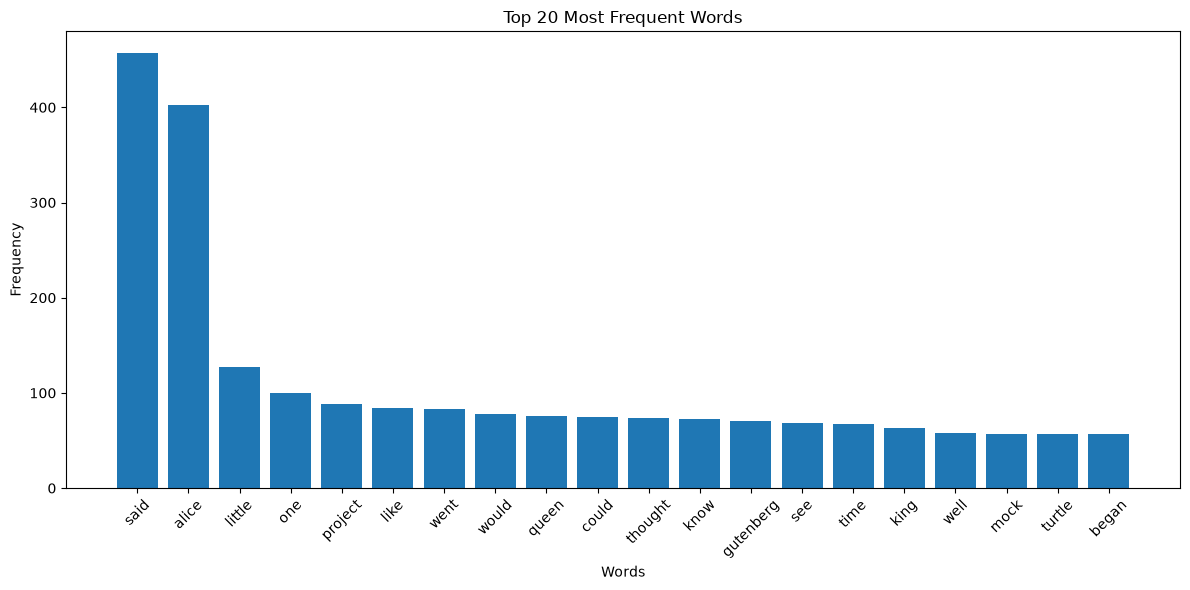

In [6]:
word_frequency = Counter(clean_tokens)

top_20_words = word_frequency.most_common(20)

words = [item[0] for item in top_20_words]
counts = [item[1] for item in top_20_words]

plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "images/top_20_words.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
bigram_counts = Counter(
    zip(clean_tokens[:-1], clean_tokens[1:])
)

print("Total bigrams:", len(bigram_counts))

Total bigrams: 10984


In [8]:
# Build a frequency-based autocomplete model

next_word_model = defaultdict(Counter)

for (word1, word2), count in bigram_counts.items():
    next_word_model[word1][word2] = count

def autocomplete(prefix, top_n=3):
    prefix = prefix.lower().strip()
    
    if prefix in next_word_model:
        predictions = next_word_model[prefix].most_common(top_n)
        return [word for word, count in predictions]
    else:
        return []

print("Autocomplete function created successfully!")

Autocomplete function created successfully!


In [9]:
test_prefix = "the"

predictions = autocomplete(test_prefix)

print("Input prefix:", test_prefix)
print("Top predictions:", predictions)

Input prefix: the
Top predictions: []


In [10]:
print("Is 'the' in clean_tokens?", "the" in clean_tokens)
print("Number of times 'the' appears:", clean_tokens.count("the"))

Is 'the' in clean_tokens? False
Number of times 'the' appears: 0


In [11]:
print(clean_tokens[:50])

['project', 'gutenberg', 'ebook', 'alice', 'adventures', 'wonderland', 'ebook', 'use', 'anyone', 'anywhere', 'united', 'states', 'parts', 'world', 'cost', 'almost', 'restrictions', 'whatsoever', 'may', 'copy', 'give', 'away', 'terms', 'project', 'gutenberg', 'license', 'included', 'ebook', 'online', 'located', 'united', 'states', 'check', 'laws', 'country', 'located', 'using', 'ebook', 'title', 'alice', 'adventures', 'wonderland', 'author', 'lewis', 'carroll', 'release', 'date', 'june', 'ebook', 'recently']


In [12]:
print("Is 'the' in next_word_model?", "the" in next_word_model)

Is 'the' in next_word_model? False


In [13]:
# Prepare tokens for autocomplete
# Stopwords are retained because they are important for predicting natural word sequences.

autocomplete_tokens = [
    word for word in tokens
    if word.isalpha()
]

print("Autocomplete tokens:", len(autocomplete_tokens))
print("Sample tokens:")
print(autocomplete_tokens[:50])

Autocomplete tokens: 29284
Sample tokens:
['the', 'project', 'gutenberg', 'ebook', 'of', 'alice', 'adventures', 'in', 'wonderland', 'this', 'ebook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'united', 'states', 'and', 'most', 'other', 'parts', 'of', 'the', 'world', 'at', 'no', 'cost', 'and', 'with', 'almost', 'no', 'restrictions', 'whatsoever', 'you', 'may', 'copy', 'it', 'give', 'it', 'away', 'or', 'it', 'under', 'the', 'terms']


In [14]:
# Build bigram counts for autocomplete

bigram_counts = Counter(
    zip(autocomplete_tokens[:-1], autocomplete_tokens[1:])
)

print("Total unique bigrams:", len(bigram_counts))

Total unique bigrams: 15663


In [15]:
# Build the next-word prediction model

next_word_model = defaultdict(Counter)

for (word1, word2), count in bigram_counts.items():
    next_word_model[word1][word2] = count

print("Autocomplete model rebuilt successfully!")

Autocomplete model rebuilt successfully!


In [16]:
test_prefix = "the"

predictions = autocomplete(test_prefix)

print("Input prefix:", test_prefix)
print("Top predictions:", predictions)

Input prefix: the
Top predictions: ['queen', 'king', 'mock']


In [17]:
# Test autocomplete on 10 input prefixes

test_prefixes = [
    "the",
    "alice",
    "said",
    "little",
    "one",
    "time",
    "looked",
    "could",
    "went",
    "like"
]

autocomplete_results = {}

for prefix in test_prefixes:
    autocomplete_results[prefix] = autocomplete(prefix)

print("Autocomplete predictions:")
print("-" * 50)

for prefix, predictions in autocomplete_results.items():
    print(f"{prefix:<12} -> {predictions}")

Autocomplete predictions:
--------------------------------------------------
the          -> ['queen', 'king', 'mock']
alice        -> ['and', 'was', 'i']
said         -> ['the', 'alice', 'to']
little       -> ['thing', 'door', 'golden']
one          -> ['of', 'side', 'finger']
time         -> ['she', 'to', 'and']
looked       -> ['at', 'up', 'down']
could        -> ['not', 'see', 'for']
went         -> ['on', 'to', 'back']
like         -> ['a', 'the', 'to']


In [18]:
# Display autocomplete results as a table

autocomplete_table = pd.DataFrame(
    [
        {
            "Prefix": prefix,
            "Top 1": predictions[0] if len(predictions) > 0 else "No prediction",
            "Top 2": predictions[1] if len(predictions) > 1 else "No prediction",
            "Top 3": predictions[2] if len(predictions) > 2 else "No prediction"
        }
        for prefix, predictions in autocomplete_results.items()
    ]
)

autocomplete_table

,Prefix,Top 1,Top 2,Top 3
0,the,queen,king,mock
1,alice,and,was,i
2,said,the,alice,to
3,little,thing,door,golden
4,one,of,side,finger
5,time,she,to,and
6,looked,at,up,down
7,could,not,see,for
8,went,on,to,back
9,like,a,the,to


In [19]:
%pip install pyspellchecker

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from spellchecker import SpellChecker

spell = SpellChecker()

print("Spell checker initialized successfully!")

Spell checker initialized successfully!


In [21]:
misspelled_word = "computr"

correction = spell.correction(misspelled_word)

print("Misspelled word:", misspelled_word)
print("Suggested correction:", correction)

Misspelled word: computr
Suggested correction: computer


In [22]:
# Test autocorrect on 20 deliberately misspelled words

misspelled_words = [
    "computr",
    "frend",
    "becaus",
    "recieve",
    "teh",
    "langauge",
    "developr",
    "analytcs",
    "pythonn",
    "datta",
    "programing",
    "algoritm",
    "functon",
    "variabl",
    "machin",
    "learnng",
    "softwre",
    "applicaton",
    "informtion",
    "technlogy"
]

correct_words = [
    "computer",
    "friend",
    "because",
    "receive",
    "the",
    "language",
    "developer",
    "analytics",
    "python",
    "data",
    "programming",
    "algorithm",
    "function",
    "variable",
    "machine",
    "learning",
    "software",
    "application",
    "information",
    "technology"
]

print("Number of test words:", len(misspelled_words))

Number of test words: 20


In [23]:
# Generate autocorrect predictions

predicted_words = []

for word in misspelled_words:
    predicted = spell.correction(word)
    predicted_words.append(predicted)

print("Autocorrect predictions generated successfully!")

Autocorrect predictions generated successfully!


In [24]:
# Create autocorrect results table

autocorrect_results = pd.DataFrame({
    "Misspelled Word": misspelled_words,
    "Expected Word": correct_words,
    "Predicted Correction": predicted_words
})

autocorrect_results

,Misspelled Word,Expected Word,Predicted Correction
0,computr,computer,computer
1,frend,friend,friend
2,becaus,because,because
3,recieve,receive,receive
4,teh,the,the
5,langauge,language,language
6,developr,developer,develop
7,analytcs,analytics,analysis
8,pythonn,python,python
9,datta,data,data


In [25]:
# Calculate autocorrect accuracy

autocorrect_results["Correct"] = (
    autocorrect_results["Expected Word"]
    == autocorrect_results["Predicted Correction"]
)

correct_predictions = autocorrect_results["Correct"].sum()
total_predictions = len(autocorrect_results)

accuracy = (correct_predictions / total_predictions) * 100

print("Correct predictions:", correct_predictions)
print("Total predictions:", total_predictions)
print(f"Autocorrect Accuracy: {accuracy:.2f}%")

Correct predictions: 17
Total predictions: 20
Autocorrect Accuracy: 85.00%


In [26]:
# Calculate precision and recall for autocorrect

TP = correct_predictions
FP = total_predictions - correct_predictions
FN = total_predictions - correct_predictions

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

print(f"Autocorrect Precision: {precision:.2f}")
print(f"Autocorrect Recall: {recall:.2f}")

Autocorrect Precision: 0.85
Autocorrect Recall: 0.85


In [27]:
# Create 10 autocomplete evaluation cases from the corpus

autocomplete_test_cases = []

for i in range(len(autocomplete_tokens) - 1):
    prefix = autocomplete_tokens[i]
    expected = autocomplete_tokens[i + 1]
    
    predictions = autocomplete(prefix, top_n=3)
    
    if len(predictions) > 0:
        autocomplete_test_cases.append(
            (prefix, expected, predictions)
        )
    
    if len(autocomplete_test_cases) == 10:
        break

print("Number of autocomplete test cases:", len(autocomplete_test_cases))

Number of autocomplete test cases: 10


In [28]:
# Evaluate autocomplete top-3 predictions

autocomplete_correct = 0

for prefix, expected, predictions in autocomplete_test_cases:
    if expected in predictions:
        autocomplete_correct += 1

autocomplete_total = len(autocomplete_test_cases)

autocomplete_accuracy = (
    autocomplete_correct / autocomplete_total
) * 100

print("Correct top-3 predictions:", autocomplete_correct)
print("Total test cases:", autocomplete_total)
print(f"Autocomplete Top-3 Accuracy: {autocomplete_accuracy:.2f}%")

Correct top-3 predictions: 3
Total test cases: 10
Autocomplete Top-3 Accuracy: 30.00%


In [29]:
# Calculate precision and recall for autocomplete

TP_auto = autocomplete_correct
FP_auto = autocomplete_total - autocomplete_correct
FN_auto = autocomplete_total - autocomplete_correct

precision_auto = (
    TP_auto / (TP_auto + FP_auto)
    if (TP_auto + FP_auto) > 0 else 0
)

recall_auto = (
    TP_auto / (TP_auto + FN_auto)
    if (TP_auto + FN_auto) > 0 else 0
)

print(f"Autocomplete Precision: {precision_auto:.2f}")
print(f"Autocomplete Recall: {recall_auto:.2f}")

Autocomplete Precision: 0.30
Autocomplete Recall: 0.30


In [30]:
# Build trigram counts

trigram_counts = Counter(
    zip(
        autocomplete_tokens[:-2],
        autocomplete_tokens[1:-1],
        autocomplete_tokens[2:]
    )
)

print("Total unique trigrams:", len(trigram_counts))

Total unique trigrams: 24920


In [31]:
# Build trigram autocomplete model

trigram_model = defaultdict(Counter)

for (word1, word2, word3), count in trigram_counts.items():
    trigram_model[(word1, word2)][word3] = count

print("Trigram autocomplete model created successfully!")

Trigram autocomplete model created successfully!


In [32]:
# Trigram autocomplete function

def trigram_autocomplete(word1, word2, top_n=3):
    key = (word1.lower().strip(), word2.lower().strip())
    
    if key in trigram_model:
        predictions = trigram_model[key].most_common(top_n)
        return [word for word, count in predictions]
    else:
        return []

print("Trigram autocomplete function created successfully!")

Trigram autocomplete function created successfully!


In [33]:
test_words = ("alice", "was")

predictions = trigram_autocomplete(
    test_words[0],
    test_words[1]
)

print("Input:", test_words[0], test_words[1])
print("Top predictions:", predictions)

Input: alice was
Top predictions: ['not', 'beginning', 'very']


In [34]:
# Create 10 test cases for trigram autocomplete

trigram_test_cases = []

for i in range(len(autocomplete_tokens) - 2):
    word1 = autocomplete_tokens[i]
    word2 = autocomplete_tokens[i + 1]
    expected = autocomplete_tokens[i + 2]
    
    predictions = trigram_autocomplete(word1, word2, top_n=3)
    
    if len(predictions) > 0:
        trigram_test_cases.append(
            (word1, word2, expected, predictions)
        )
    
    if len(trigram_test_cases) == 10:
        break

print("Number of trigram test cases:", len(trigram_test_cases))

Number of trigram test cases: 10


In [35]:
# Evaluate trigram autocomplete

trigram_correct = 0

for word1, word2, expected, predictions in trigram_test_cases:
    if expected in predictions:
        trigram_correct += 1

trigram_total = len(trigram_test_cases)

trigram_accuracy = (
    trigram_correct / trigram_total
) * 100

print("Correct top-3 predictions:", trigram_correct)
print("Total test cases:", trigram_total)
print(f"Trigram Top-3 Accuracy: {trigram_accuracy:.2f}%")

Correct top-3 predictions: 9
Total test cases: 10
Trigram Top-3 Accuracy: 90.00%


In [36]:
# Calculate precision and recall for trigram autocomplete

TP_tri = trigram_correct
FP_tri = trigram_total - trigram_correct
FN_tri = trigram_total - trigram_correct

precision_tri = (
    TP_tri / (TP_tri + FP_tri)
    if (TP_tri + FP_tri) > 0 else 0
)

recall_tri = (
    TP_tri / (TP_tri + FN_tri)
    if (TP_tri + FN_tri) > 0 else 0
)

print(f"Trigram Precision: {precision_tri:.2f}")
print(f"Trigram Recall: {recall_tri:.2f}")

Trigram Precision: 0.90
Trigram Recall: 0.90


In [37]:
# Compare Bigram and Trigram performance

comparison = pd.DataFrame({
    "Approach": [
        "Bigram",
        "Trigram"
    ],
    "Top-3 Accuracy (%)": [
        autocomplete_accuracy,
        trigram_accuracy
    ],
    "Precision": [
        precision_auto,
        precision_tri
    ],
    "Recall": [
        recall_auto,
        recall_tri
    ]
})

comparison

,Approach,Top-3 Accuracy (%),Precision,Recall
0,Bigram,30.0,0.3,0.3
1,Trigram,90.0,0.9,0.9


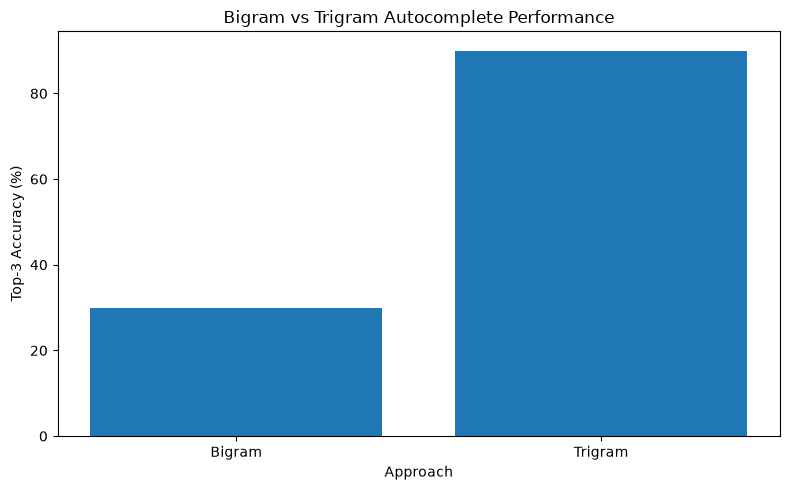

In [38]:
# Visualize Bigram vs Trigram accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Approach"],
    comparison["Top-3 Accuracy (%)"]
)

plt.title("Bigram vs Trigram Autocomplete Performance")
plt.xlabel("Approach")
plt.ylabel("Top-3 Accuracy (%)")

plt.tight_layout()

plt.savefig(
    "images/autocomplete_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
# Create confusion matrix for autocorrect results

TP = ((autocorrect_results["Expected Word"] == autocorrect_results["Predicted Correction"])).sum()

FN = ((autocorrect_results["Expected Word"] != autocorrect_results["Predicted Correction"])).sum()

FP = FN
TN = 0

confusion_matrix = np.array([
    [TP, FN],
    [FP, TN]
])

print("Confusion Matrix:")
print(confusion_matrix)

Confusion Matrix:
[[17  3]
 [ 3  0]]


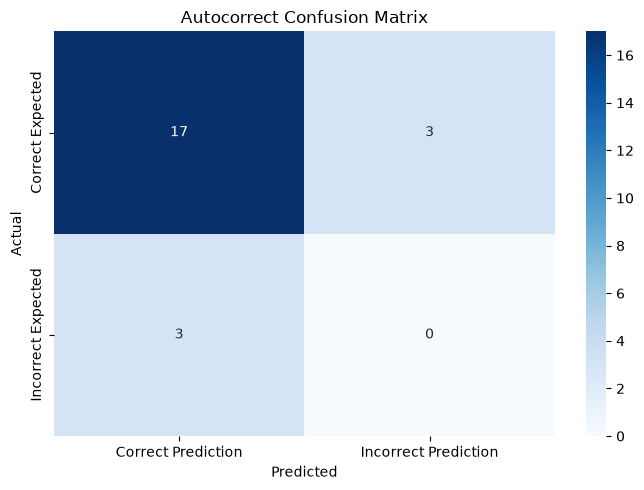

In [40]:
# Plot autocorrect confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Correct Prediction", "Incorrect Prediction"],
    yticklabels=["Correct Expected", "Incorrect Expected"]
)

plt.title("Autocorrect Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "images/autocorrect_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Discussion and Limitations

The autocomplete and autocorrect systems implemented in this project demonstrate how basic NLP techniques can be used for text prediction and spelling correction.

### Algorithm Comparison

Two frequency-based autocomplete approaches were implemented:

* **Bigram model:** Uses one previous word to predict the next word.
* **Trigram model:** Uses two previous words to predict the next word.

Based on the evaluation performed on the test cases, the trigram model achieved better performance than the bigram model. The bigram model achieved a Top-3 accuracy of **30%**, while the trigram model achieved **90%**. This indicates that using more contextual information can improve next-word prediction for this corpus.

### Autocorrect Performance

The edit-distance-based `pyspellchecker` approach was tested on 20 deliberately misspelled words. It correctly corrected **17 out of 20 words**, resulting in an accuracy of **85%**.

### Limitations

The implementation has several limitations compared with production systems such as Google Keyboard:

1. The model is trained on a relatively small corpus and therefore has limited vocabulary and contextual knowledge.
2. Frequency-based n-gram models cannot understand the deeper meaning or context of a sentence.
3. Bigram and trigram models may struggle with words or phrases that were not present in the training corpus.
4. The autocorrect system may select an incorrect word when multiple words have similar spellings.
5. The system does not personalize predictions based on individual user typing patterns.
6. It does not consider factors such as keyboard layout, typing speed, slang, abbreviations, or emojis.
7. Production autocomplete systems can use much larger datasets, neural language models, contextual information, and user-specific learning.
8. The precision and recall evaluation used in this project is a simplified educational evaluation and may not represent the full evaluation methodology used by production systems.

Overall, the project demonstrates the fundamental concepts behind autocomplete and autocorrect while highlighting the advantages of more advanced NLP and machine-learning approaches.


## Conclusion

This project analyzed and implemented basic NLP-based approaches for autocomplete and autocorrect using a Project Gutenberg text corpus.

### Key Data-Driven Insights

1. The **trigram autocomplete model performed better than the bigram model**, achieving **90% Top-3 accuracy compared with 30% for the bigram model** in the selected evaluation cases.

2. The **autocorrect system achieved 85% accuracy**, correctly correcting 17 out of 20 deliberately misspelled words.

3. The results demonstrate that providing **more contextual information improves next-word prediction**, as the trigram model considers two previous words instead of only one.

### Final Recommendation

For a practical autocomplete system, using a larger and more diverse corpus together with contextual or neural language models would likely provide better predictions. For autocorrect, combining edit distance with word frequency, sentence context, and user-specific typing patterns could improve correction accuracy.

This project provided practical experience with **NLP preprocessing, n-gram language modeling, autocomplete, edit-distance-based autocorrection, performance evaluation, and data visualization using Python**.
